# **03. [Cervical] Survival Curves**

## **Introduction**
Generation of survival curves for the machine learning survival analysis (MLSA) models. The RSF and GBSA model curves are natively produced by the models, while the SSVM curve was adapted to represent probabilities over time. No curve adaptations were found for the XGB-Cox, XGB-AFT, and LGBM models that satisfied the theoretical assumptions.

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Mounted at /content/drive
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 2

Lendo dependências de ml:
  - cmaes==0.13.0
  - lifelines==0.30.3
  - lightgbm==4.6.0
  - matplotlib==3.10.0
  - numpy==2.0.2
  - optuna==4.8.0
  - pandas==2.2.2
  - scikit-learn==1.8.0
  - scikit-survival==0.27.0
  - scipy==1.16.3
  - shap==0.51.0
  - xgboost==3.2.0

 Instalando dependências necessárias:
 + cmaes==0.13.0
 + lifelines==0.30.3
 + optuna==4.8.0
 + scikit-learn==1.8.0
 + scikit-survival==0.27.0
 + shap==0.51.0

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

In [ ]:
# Imports
import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score, integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## Seed

In [ ]:
seed = 1

## Functions

In [ ]:
# Importing the functions
!gdown 1-uw7N4Vx5eNLso_NQ64uObFTlwXhdnda --quiet

from functions_ml_survival import *

# **Survival models**
Plot of the MLSA model curves.

## **Train e Test**

Dividing the database into training and testing components.

In [ ]:
# Cervical Dataset
!gdown 17QhaZ29-zkLMeISA0CeDktYJ7HZ4yQ3V --quiet

In [ ]:
# Reading data
df_colo_utero = pd.read_csv('colo_utero.csv')
print(df_colo_utero.shape)
df_colo_utero.head(3)

(50615, 49)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_REC,PRESENCA_META,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,21423,2,43,3506003,9,1,C539,80703,IB,I,...,0,0,0,0,1,1,0,0,0,11
1,8,9,32,3550308,9,1,C539,80102,0,0,...,0,0,0,0,0,0,1,1,1,61
2,8,9,40,3505708,9,2,C539,80102,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Exclude patients with EC = 0 (In Situ)
df_colo_utero = df_colo_utero[df_colo_utero.ECGRUP_CAT != 'In Situ']

# Exclude patients with morphology ending in 2
df_colo_utero = df_colo_utero[~df_colo_utero['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df_colo_utero = df_colo_utero[~df_colo_utero.MORFO.isin([90703, 91103])]

df_colo_utero.shape

(27850, 49)

In [ ]:
# Columns
df_colo_utero.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_REC', 'PRESENCA_META', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Overall Survival
df_colo_utero['obito_geral'].value_counts()

,count
obito_geral,
0,15333
1,12517


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_colo_utero.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_colo_utero['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (22280, 48)
y_train: (22280,)
X_test: (5570, 48)
y_test: (5570,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

# Save the DataFrames to CSV files
df_treino.to_csv('colo_utero_treino.csv', index=False)  # Save the training DataFrame to 'colo_utero_treino.csv'
df_teste.to_csv('colo_utero_teste.csv', index=False)  # Save the testing DataFrame to 'colo_utero_teste.csv'

## **Kaplan-Meier**

The Kaplan-Meier method will be used as the baseline for comparison with the survival model curves.

In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colo_utero_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(5570, 49)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20435,3,54,3538709,9,2,C539,81403,IIB,II,...,2,2,0,0,0,1,1,1,61,0
1,21636,2,68,3507001,9,2,C539,80703,IIIA,III,...,0,2,0,0,0,1,1,1,61,0
2,16667,4,57,3550308,2,1,C530,83843,IIB,II,...,1,0,0,0,1,1,0,0,29,1


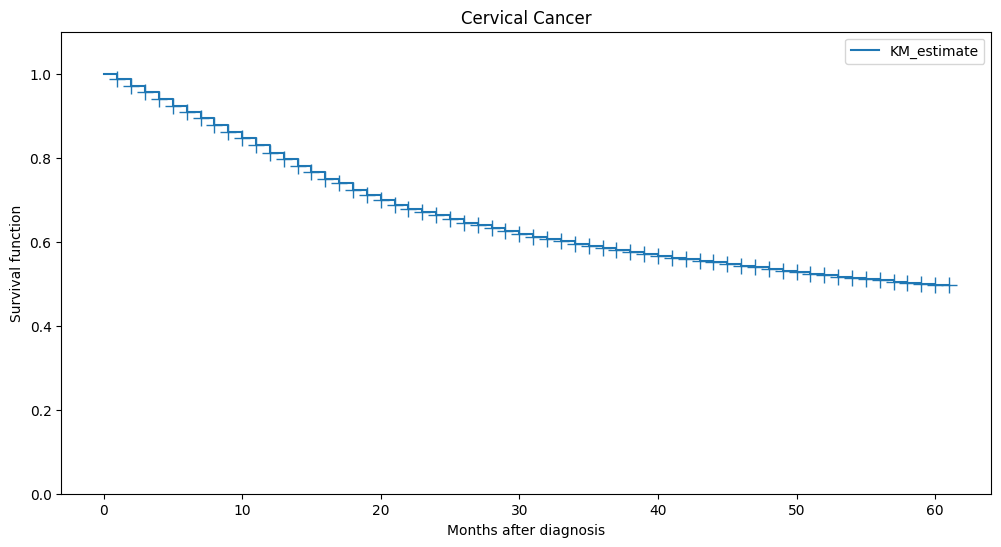

In [ ]:
# Kaplan-Meier Survival Curve Plot
# Extract event (E) and time (T) data from the test set
E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

title = f'Cervical Cancer'  # Set the plot title

kmf = KaplanMeierFitter()  # Initialize the Kaplan-Meier fitter

fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Fit and plot the Kaplan-Meier survival curve
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)  # Fit the model, plot the curve, show censoring marks
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set the x-axis label
ax.set_ylabel('Survival function')  # Set the y-axis label
plt.ylim([0, 1.1])  # Set y-axis limits
plt.show()  # Display the plot

## **Machine Learning Survival**

Training of the 'best models' of the study, identified in the [survival models notebook](https://drive.google.com/file/d/1srm5HZRTX3FMC0kslFOrr0I2nTebYf89/view?usp=sharing).

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('colo_utero_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(22280, 49)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,16667,9,58,3550308,9,1,C539,80703,IB,I,...,2,0,0,0,0,0,0,0,1,0
1,16624,2,52,3547304,2,2,C539,81403,IVB,IV,...,0,1,0,1,1,0,0,0,8,1
2,3,9,38,3543907,9,1,C539,81403,IA,I,...,2,0,0,0,0,1,1,1,61,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('colo_utero_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(5570, 49)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20435,3,54,3538709,9,2,C539,81403,IIB,II,...,2,2,0,0,0,1,1,1,61,0
1,21636,2,68,3507001,9,2,C539,80703,IIIA,III,...,0,2,0,0,0,1,1,1,61,0
2,16667,4,57,3550308,2,1,C530,83843,IIB,II,...,1,0,0,0,1,1,0,0,29,1


In [ ]:
# # Exclusão da linha que estava com ULTDIAG negativa
# df_treino = df_treino[df_treino.ULTIDIAG >= 0]
# df_treino.shape

In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'obito_geral',
             'obito_cancer', 'meses_diag', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO',
             'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS',
             'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS',
             'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST',
             'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((22280, 16), (5570, 16))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Models**

**RSF**

C-Index Test: 0.7663586430329856
C-Index Train: 0.7914892954104124

C-Index IPCW Test: 0.7582776272557842
C-Index IPCW Train: 0.7840526878502665

Integrated Brier Score (IBS): 0.14811273181757761

Brier Score:
    > 1 year = 0.11135485509135296
    > 3 years = 0.17667361367346937
    > 5 years = 0.18029880468489629



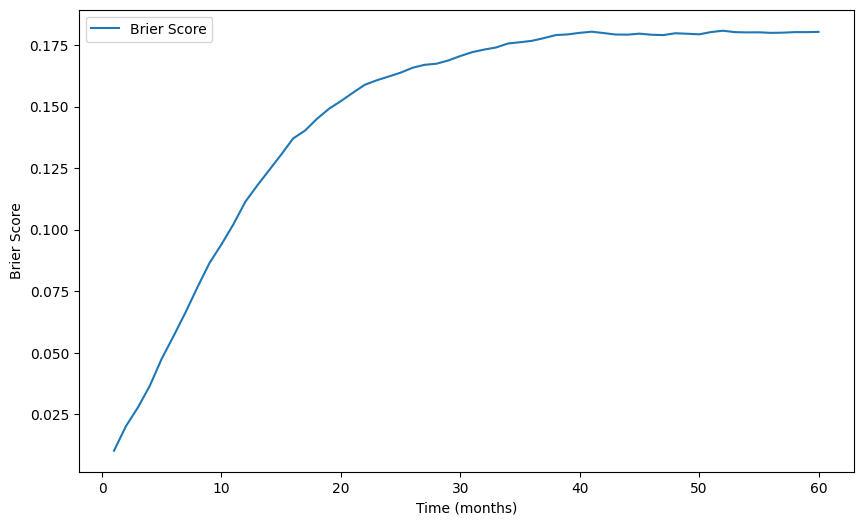

In [ ]:
%%time

rsf = RandomSurvivalForest(max_depth=10, max_features=0.5, min_samples_leaf=9,
                           min_samples_split=11, n_estimators=116,
                           random_state=seed)

rsf.fit(X_train, y_train)

# Metrics of the best RSF model
final_c_index = rsf.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)

**GBS**

C-Index Test: 0.7722168087254827
C-Index Train: 0.7962124598207879

C-Index IPCW Test: 0.7643104444675533
C-Index IPCW Train: 0.7887741501587088

Integrated Brier Score (IBS): 0.14727745947239826

Brier Score:
    > 1 year = 0.11184710571513062
    > 3 years = 0.17469730632147507
    > 5 years = 0.1783009365828702



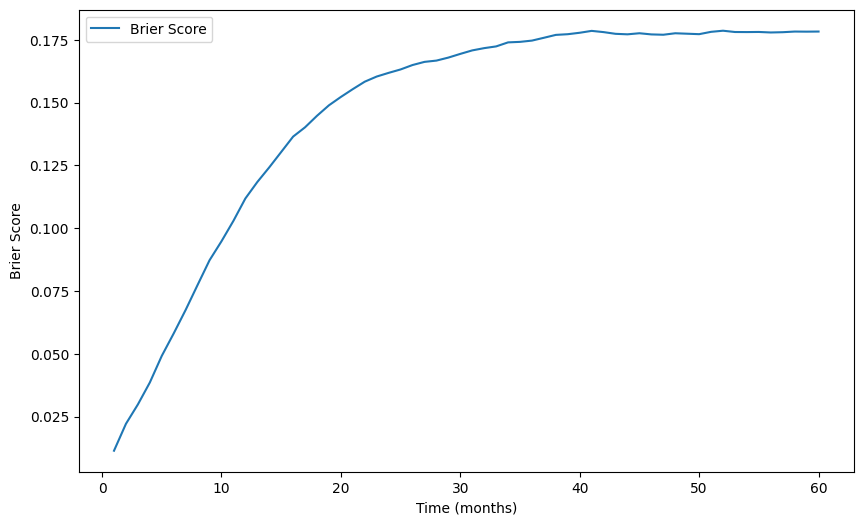

In [ ]:
%%time

gb = GradientBoostingSurvivalAnalysis(learning_rate=0.18, max_depth=6,
                                      max_features='log2', min_samples_leaf=8,
                                      min_samples_split=10, n_estimators=108,
                                      random_state=seed, subsample=0.9)

gb.fit(X_train, y_train)  # Fit the Gradient Boosting model on the training data

# Metrics of the best GBS model
final_c_index = gb.score(X_test, y_test)  # Compute the C-index for the best model on the test dataset

print(f'C-Index Test: {final_c_index}')  # Print the C-index for the test set
print(f'C-Index Train: {gb.score(X_train, y_train)}\n')  # Print the C-index for the training set

# Calculate and print the IPCW and Brier score for the best model
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test)

In [ ]:
colo_utero = {
    'gb': gb
}

with open('colo_utero.pkl', 'wb') as f:
    pickle.dump(colo_utero, f)

In [ ]:
with open('colo_utero.pkl', 'rb') as f:
    colo_utero = pickle.load(f)

colo_utero

{'gb': GradientBoostingSurvivalAnalysis(learning_rate=0.18, max_depth=6,
                                  max_features='log2', min_samples_leaf=8,
                                  min_samples_split=10, n_estimators=108,
                                  random_state=1, subsample=0.9)}

Gráfico - Permutation Importance e SHAP

In [ ]:
best = colo_utero['gb']
best

,loss,'coxph'
,learning_rate,0.18
,n_estimators,108
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,10
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,random_state,1


PermutationExplainer explainer: 5571it [13:02,  7.08it/s]


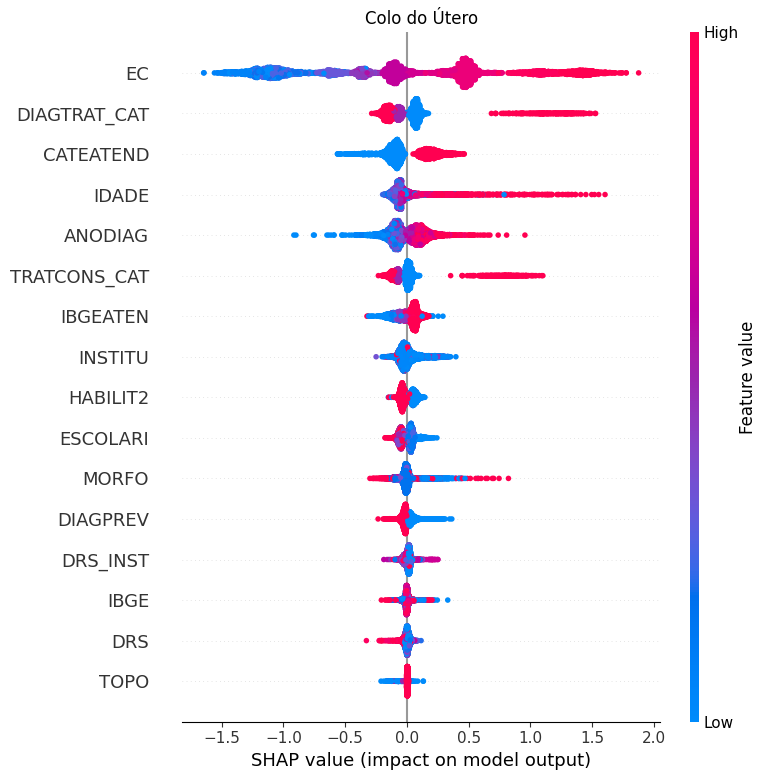

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

plt.title('Colo do Útero')
# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)

plt.tight_layout()
plt.savefig("colo_utero.svg");

PermutationExplainer explainer: 5571it [12:10,  7.51it/s]


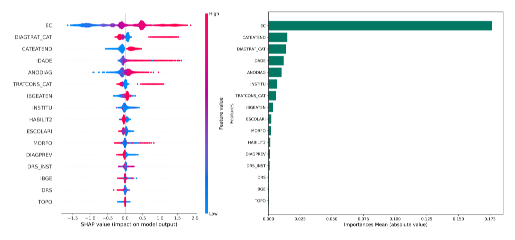

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.image as mpimg

# Best features by permutation importance
permutation_importance = calculate_permutation_importance(gb, X_test, y_test, feat_cols, random_state=seed)

# Create a SHAP TreeExplainer for the best model
explainer = shap.Explainer(gb.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Save the SHAP summary_plot to a temporary file
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)
plt.tight_layout()
plt.savefig("shap_plot.png", dpi=600, bbox_inches='tight')
plt.close()

# If 'feature' is in index, reset to column
if permutation_importance.index.name is not None:
    permutation_importance = permutation_importance.reset_index()

permutation_importance['features'] = permutation_importance.index

# Plot and save bar chart of your table
fig, ax = plt.subplots(figsize=(10,8))
permutation_importance_sorted = permutation_importance.sort_values('importances_mean', ascending=False)
ax.barh(permutation_importance_sorted['features'], permutation_importance_sorted['importances_mean'].abs(), color='#007863')
ax.set_xlabel('Importances Mean (absolute value)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
# ax.set_title("Permutation Importance em módulo")
# fig.text(0.5, -0.02, 'Importances Mean (absolute value)', ha='center', fontsize=14)
ax.invert_yaxis()  # mantém o mais importante no topo
plt.tight_layout()
plt.savefig("bar_plot.png", dpi=600, bbox_inches='tight')
plt.close()

# Open and combine images side by side with PIL
img1 = Image.open("shap_plot.png").convert("RGB")
img2 = Image.open("bar_plot.png").convert("RGB")

# Resize the height of the second image to match the height of the first (if necessary)
if img1.height != img2.height:
    img2 = img2.resize((img2.width, img1.height))

# Ensure same height
max_height = max(img1.height, img2.height)
total_width = img1.width + img2.width

# New combined image
combined_img = Image.new('RGB', (total_width, max_height), color=(255, 255, 255))
combined_img.paste(img1, (0, 0))
combined_img.paste(img2, (img1.width, 0))

# Save
combined_img.save("PI_SHAP_cervical_charts.png", dpi=(300, 300), quality=95, optimize=True)
combined_img.save("PI_SHAP_cervical_charts.eps", dpi=(300, 300), quality=95, optimize=True)

img = mpimg.imread("PI_SHAP_cervical_charts.png")
plt.imshow(img)
plt.axis('off')
plt.show()

**SSVM**

In [ ]:
%%time

ssvm = FastSurvivalSVM(alpha=0.001, optimizer='avltree', random_state=seed,
                       rank_ratio=0.9, tol=0.0001)

ssvm.fit(X_train, y_train)  # Fit the Fast Survival SVM model on the training data

# C-Index Calculation
print('C-Index')
print(f'> Test: {ssvm.score(X_test, y_test)}')  # Calculate and print the C-index for the test set
print(f'> Train: {ssvm.score(X_train, y_train)}')  # Calculate and print the C-index for the training set

# C-Index IPCW Calculation
surv_risks = ssvm.predict(X_test)  # Predict survival risks for the test set
surv_risks_train = ssvm.predict(X_train)  # Predict survival risks for the training set

# Compute IPCW C-index for test and train sets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # IPCW C-index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # IPCW C-index for the train set

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print the IPCW C-index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-index for the training set

C-Index
> Test: 0.7372484088217304
> Train: 0.7376500493488359

C-Index IPCW
> Test: 0.7315003123234739
> Train: 0.7318279771498913
CPU times: user 9.1 s, sys: 15.2 ms, total: 9.12 s
Wall time: 11.1 s


Curve adaptation (through Cox model calibration).

Brier Score at 12 months: 0.13095047914749852
Brier Score at 36 months: 0.19003583351787676
Brier Score at 60 months: 0.1921823725803107

Integrated Brier Score (IBS): 0.16299351609388463


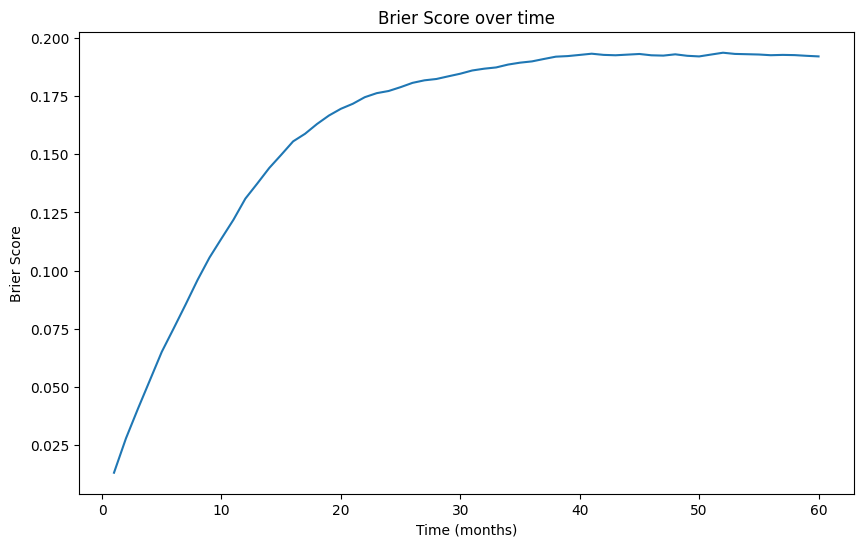

In [ ]:
from lifelines import CoxPHFitter
from sksurv.util import Surv

#Preparing dataframe for Cox Model training
event = y_test["event"]
time = y_test["time"]
df_cox = pd.DataFrame({
    "time": time,
    "event": event,
    "ssvm_score": surv_risks
})

#Fitting the Cox model with the predicted score as a covariate
cox = CoxPHFitter()
cox.fit(df_cox, duration_col="time", event_col="event")

# Generating individual curves (each column is a patient)
surv_funcs = cox.predict_survival_function(df_cox)
surv_funcs.drop(surv_funcs.index[-1], axis=0, inplace=True) #Censoring month 61
surv_ssvm_mean = surv_funcs.mean(axis=1)

#Brier Scores and Integrated Brier Score

time_points = np.arange(1, 61, 1)
surv_preds = surv_funcs.values.T

brier_scores = brier_score(
    y_train,  # Training data is used to estimate the censoring distribution
    y_test,   # Test data
    surv_preds,
    time_points
)

ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_preds,
    time_points)

print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

**XGB-Cox**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign higher weights to events (1.0 for event and 0.15 for non-event)

params = {'n_estimators': 110, 'learning_rate': 0.07, 'max_depth': 5,
          'min_child_weight': 4, 'subsample': 0.9, 'colsample_bytree': 0.85,
          'reg_alpha': 1, 'reg_lambda': 0.0001}

params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
               'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
               'random_state': seed,  # Set the random seed for reproducibility
               'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cox = xgb.train(params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_cox.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cox.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

print('C-Index')  # Print label for C-Index
print(f'> Test: {c_index}')  # Print C-Index for the test set
print(f'> Train: {c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7451715333569275
> Train: 0.7655133144592381

C-Index IPCW
> Test: 0.7374889817272151
> Train: 0.7568762966330727


Brier Score at 12 months: 0.12668586433335893
Brier Score at 36 months: 0.2118555767223196
Brier Score at 60 months: 0.2204676789645817

Integrated Brier Score (IBS): 0.17647850618194133


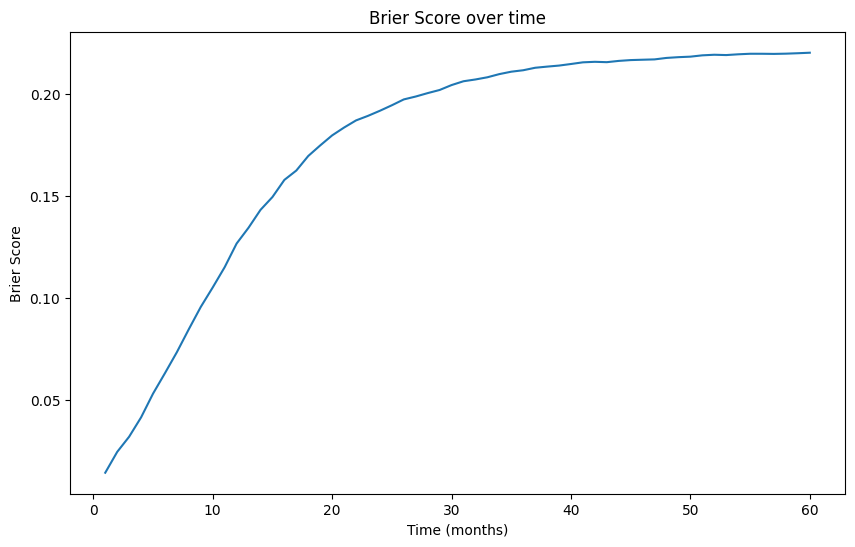

In [ ]:
# Center and standardize the risks (avoid min-max normalization)
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert risks to hazard ratios (if the SSVM returns log-hazard values)
hazard_ratio = np.exp(surv_risks_scaled)  # Adjust this conversion as needed based on the model output

# Calculate the baseline survival curve on the training data using the Kaplan-Meier estimator
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute the smoothed baseline hazard by taking the negative logarithm of the survival probability
baseline_hazard = -np.log(survival_prob_train + 1e-8)  # Add a small constant to avoid log(0)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)  # Replace NaNs and infinities with 0

# Calculate S(t) = exp(-HR * H0(t)) for the test set, where HR is the hazard ratio and H0(t) is the baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points of interest (ensuring they fall within the observed range)
time_points = np.arange(1, 61, 1)  # From 1 to 60 months

# Perform stepwise interpolation (similar to Kaplan-Meier step functions)
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',  # Important for maintaining a step function behavior
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Conservative extrapolation: 1.0 before and 0.0 after the known range
)

# Obtain the interpolated survival probabilities for the defined time points
surv_probs_interp = interp_func(time_points)

# Enforce monotonicity: ensure survival probabilities do not increase over time
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip values to ensure they are within valid bounds [0, 1]
surv_xgbcox_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbcox_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbcox_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, and 60 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

**XGB-AFT**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.4)  # Assign higher weights to events (1.0 for event and 0.4 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

params = {'n_estimators': 52, 'learning_rate': 0.21, 'max_depth': 4,
          'min_child_weight': 8, 'subsample': 1.0, 'colsample_bytree': 0.9,
          'reg_alpha': 10, 'reg_lambda': 0.0001,
          'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.55}  # Get the best parameters from the study

params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
               'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
               'random_state': seed,  # Seed for reproducibility
               'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_aft.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_aft.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

print('C-Index')  # Print label for C-Index
print(f'> Test: {c_index}')  # Print C-Index for the test set
print(f'> Train: {c_index_train}')  # Print C-Index for the training set

# Calculate the C-Index IPCW (Inverse Probability of Censoring Weight)
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7725936400681217
> Train: 0.7858152880949443

C-Index IPCW
> Test: 0.7639449649617118
> Train: 0.7766876996791785


Brier Score at 12 months: 0.22638130297632647
Brier Score at 36 months: 0.3662158921206959
Brier Score at 60 months: 0.37857284515792833

Integrated Brier Score (IBS): 0.30742328350988535


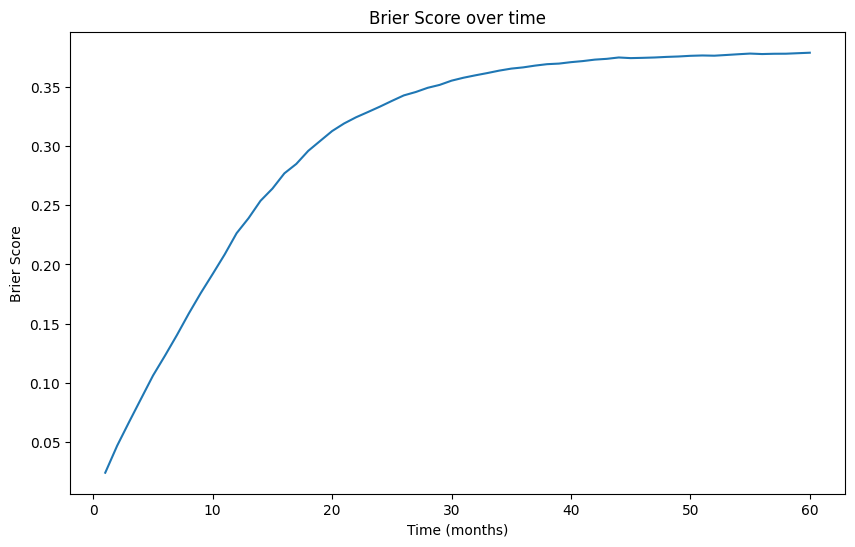

In [ ]:
# Standardize predicted risk scores using StandardScaler to ensure zero mean and unit variance
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert standardized risk scores to hazard ratios using exponential transformation
hazard_ratio = np.exp(surv_risks_scaled)

# Calculate Kaplan-Meier survival probabilities for the training data
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute baseline hazard by taking the negative log of survival probabilities (add small epsilon to avoid log(0))
# Replace NaN/Inf values with 0 to ensure numerical stability
baseline_hazard = -np.log(survival_prob_train + 1e-8)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)

# Calculate survival probabilities for test data using hazard ratios and baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points for evaluation (1 to 60 months)
time_points = np.arange(1, 61, 1)

# Create interpolation function for survival probabilities using the training time grid
# Uses "previous" interpolation to align with stepwise nature of survival curves
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Extend with 1.0 (survival) before first time point and 0.0 after last
)

# Interpolate survival probabilities to predefined monthly time points
surv_probs_interp = interp_func(time_points)
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip survival probabilities to valid [0.0, 1.0] range
surv_xgbaft_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbaft_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_xgbaft_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, and 60 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

**LGBM**

In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the necessary model settings
params = {'n_estimators': 108, 'learning_rate': 0.12, 'max_depth': 5,
          'num_leaves': 75, 'min_child_samples': 15, 'subsample': 0.65,
          'colsample_bytree': 0.5, 'reg_alpha': 0.01, 'reg_lambda': 0.0001}

params.update({'objective': 'regression',  # Using Cox regression for survival analysis
               'metric': 'rmse',  # Root Mean Squared Error metric for monitoring performance
               'seed': seed,  # Set the random seed for reproducibility
               'verbose': -1,  # Suppress output during training
               'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)

# Train the LightGBM model with the best parameters found by Optuna
lgbm = lgb.train(params, dtrain, num_boost_round=100)

# Make predictions on both the validation and training sets
y_pred = lgbm.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print('C-Index')
print(f'> Test: {c_index}')  # Print the C-Index for the test set
print(f'> Train: {c_index_train}')  # Print the C-Index for the training set

# Calculate IPCW C-Index
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # Compute IPCW C-Index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # Compute IPCW C-Index for the training set

# Display IPCW C-Index results
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7483122622717042
> Train: 0.7727157253513733

C-Index IPCW
> Test: 0.7404211133864209
> Train: 0.7628308849643535


Brier Score at 12 months: 0.2560329642172572
Brier Score at 36 months: 0.45711653023671994
Brier Score at 60 months: 0.47487066986886495

Integrated Brier Score (IBS): 0.37545600735232326


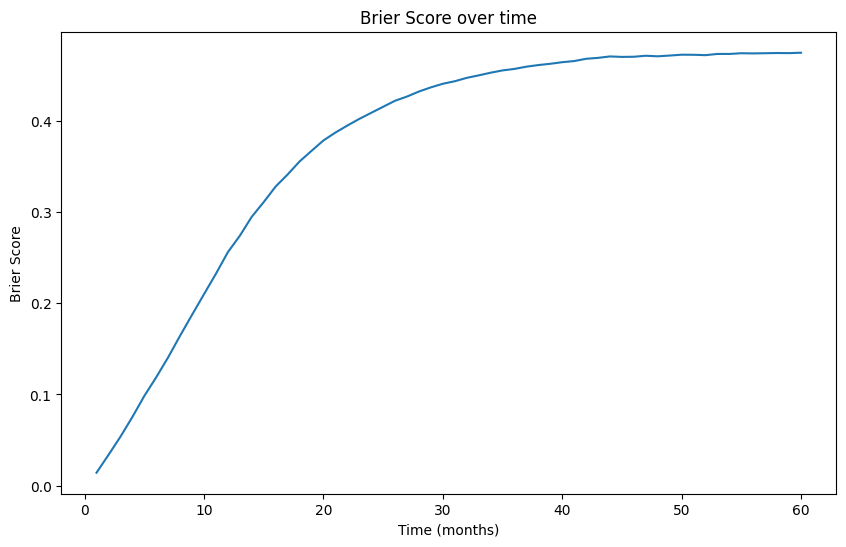

In [ ]:
# Standardize predicted risk scores using StandardScaler to ensure zero mean and unit variance
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert standardized risk scores to hazard ratios using exponential transformation
hazard_ratio = np.exp(surv_risks_scaled)

# Calculate Kaplan-Meier survival probabilities for the training data
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute baseline hazard by taking the negative log of survival probabilities (add small epsilon to avoid log(0))
# Replace NaN/Inf values with 0 to ensure numerical stability
baseline_hazard = -np.log(survival_prob_train + 1e-8)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)

# Calculate survival probabilities for test data using hazard ratios and baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points for evaluation (1 to 60 months)
time_points = np.arange(1, 61, 1)

# Create interpolation function for survival probabilities using the training time grid
# Uses "previous" interpolation to align with stepwise nature of survival curves
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Extend with 1.0 (survival) before first time point and 0.0 after last
)

# Interpolate survival probabilities to predefined monthly time points
surv_probs_interp = interp_func(time_points)
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip survival probabilities to valid [0.0, 1.0] range
surv_lgbm_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_lgbm_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_lgbm_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, and 60 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

# **Curves**
Plot final curves.

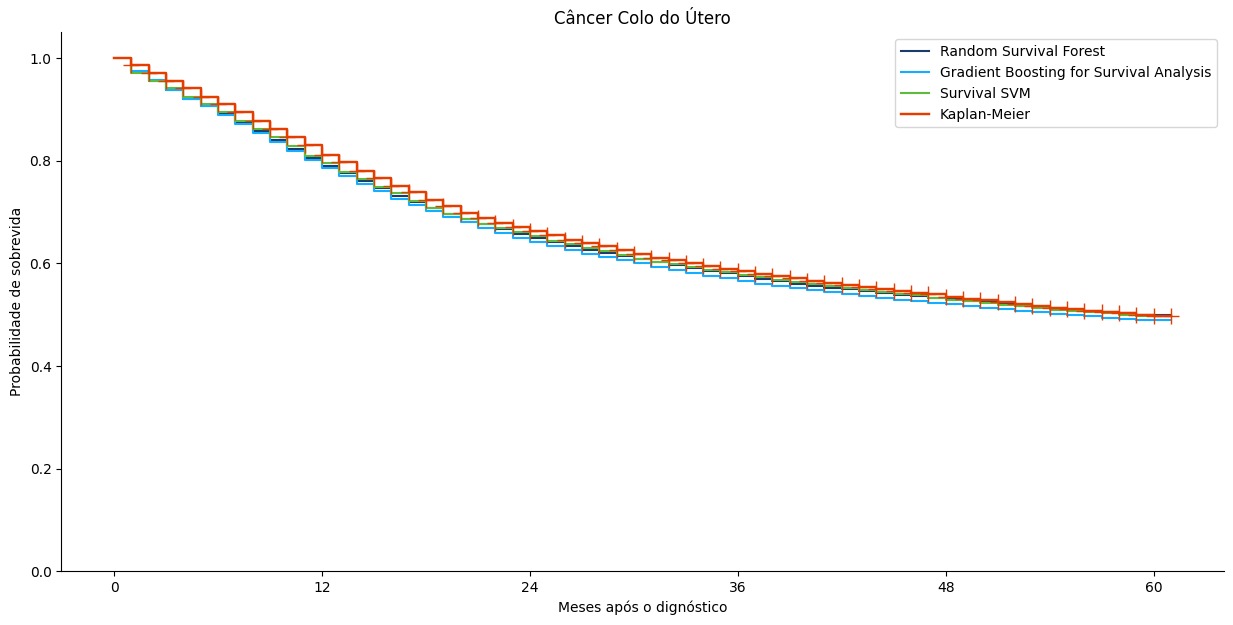

In [ ]:
# KM
fig = plt.figure(figsize=(15, 7))
ax = plt.subplot(111)

E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

colors = [
          '#E53D00',
          '#1B3B6F',
          '#15ADFF',
          '#5FBB3B'
        ]

times = rsf.unique_times_
lstyle = 'solid'

surv_rsf = rsf.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)
ax.step(times, surv_rsf_mean, linestyle=lstyle, color=colors[1],
        label='Random Survival Forest')

surv_gb = gb.predict_survival_function(X_test, return_array=True)
surv_gb_mean = surv_gb.mean(axis=0)
ax.step(times, surv_gb_mean, linestyle=lstyle, color=colors[2],
        label='Gradient Boosting for Survival Analysis')

# surv_ssvm_mean = surv_ssvm_final.mean(axis=0)
ax.step(times[:-1], surv_ssvm_mean, linestyle=lstyle, color=colors[3],
        label='Survival SVM')

ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True,
                        label='Kaplan-Meier', color=colors[0],
                        linewidth=1.75)

title = f'Câncer Colo do Útero'  # Set the plot title
ax.set_title(title)
ax.set_xlabel('Meses após o dignóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, rsf.unique_times_[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.05])
plt.legend()

plt.savefig('curvas_colo_utero.svg')

# **Results**
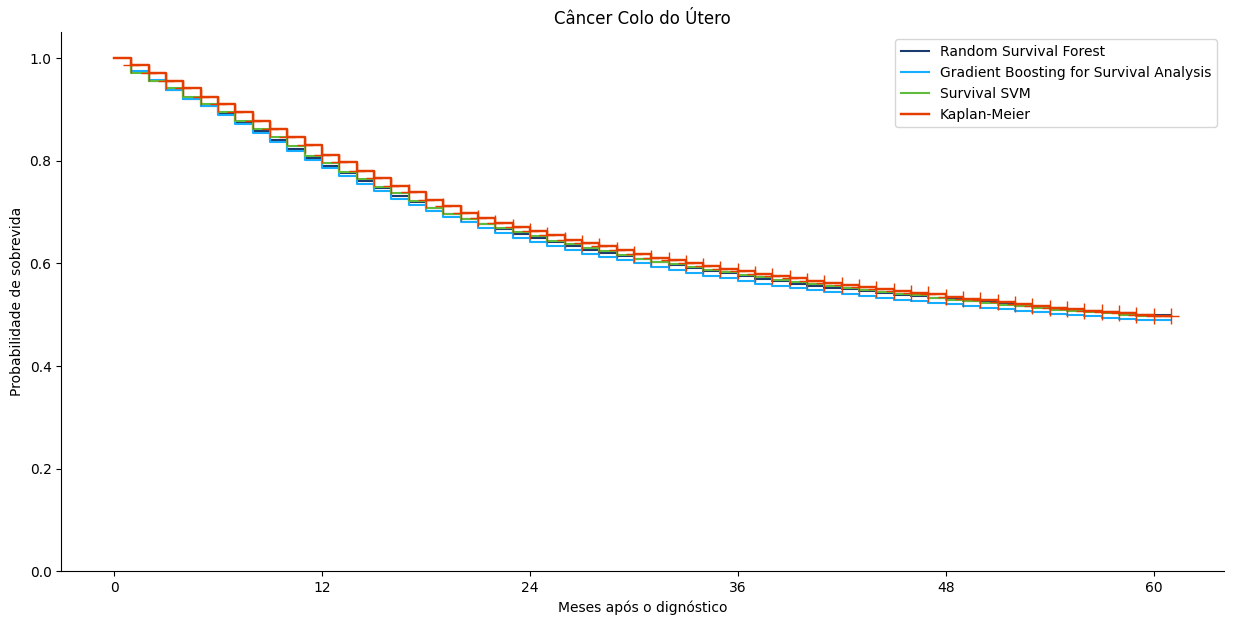

## Requirements Synchronization

In [ ]:
sync("ml", ["xgboost", "lightgbm", "scipy"])

[OK] xgboost já registrado (3.2.0)
[OK] lightgbm já registrado (4.6.0)
[OK] scipy já registrado (1.16.3)

Nenhuma alteração realizada.
